# 03 · Análisis estadístico

**Objetivo:** determinar si existen diferencias estadísticamente significativas entre los siete *samplers* evaluados sobre los 20 problemas ZCAT, y cuantificar el tamaño de esas diferencias.

**Procedimiento (test no paramétrico para diseños de bloques, estándar en la literatura de optimización):**

1. **Test de Friedman** — ¿existen diferencias significativas entre los 7 *samplers* considerando los 20 problemas como bloques?
2. **Post-hoc de Nemenyi** — si Friedman es significativo, ¿qué pares de *samplers* difieren entre sí?
3. **Critical Difference Diagram** — representación visual estándar de los rankings medios y los grupos estadísticamente indistinguibles.
4. **Vargha-Delaney A12** — tamaño del efecto entre cada par de *samplers*, complementario al p-valor (indica no solo *si* hay diferencia sino *cuán grande* es).


## Imports

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

from pathlib import Path

DATA_DIR = Path("../data/processed")
FIGURES_DIR = Path("../data/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ALPHA = 0.05

## Cargar los datos

In [2]:
study_summary = pd.read_csv(DATA_DIR / "study_summary_normalized.csv")
study_summary.head()

,sampler,problem,n_trials,hv,mean_value,std_value,total_duration,mean_trial_duration,hv_norm,rank
0,cmaes,zcat1,50,0.254027,0.153123,0.089824,4518.993983,90.379879,0.505914,4.0
1,cmaes,zcat10,50,0.112726,0.068460,0.040746,5614.772873,112.295457,0.870393,3.0
2,cmaes,zcat11,50,0.210841,0.117430,0.077371,4183.296339,83.665926,0.000000,7.0
3,cmaes,zcat12,50,0.195056,0.127362,0.072957,3571.041948,71.420838,0.439294,5.0
4,cmaes,zcat13,50,0.249413,0.154064,0.093711,5403.319708,108.066394,0.830539,4.0


## Construcción de la matriz problema × sampler

Los tests de Friedman y Nemenyi requieren un diseño de bloques completo: una fila por problema, una columna por *sampler*, con el HV como valor.


In [3]:
matrix = study_summary.pivot(index="problem", columns="sampler", values="hv")
matrix

sampler,cmaes,gp,nsgaii,nsgaiii,qmc,random,tpe
problem,,,,,,,
zcat1,0.254027,0.254272,0.256574,0.253001,0.251419,0.251604,0.254913
zcat10,0.112726,0.108723,0.112842,0.112205,0.110380,0.112053,0.113323
zcat11,0.210841,0.215117,0.214032,0.210936,0.216718,0.212445,0.215173
zcat12,0.195056,0.200905,0.197902,0.198601,0.193614,0.190232,0.201214
zcat13,0.249413,0.234134,0.249635,0.248369,0.252531,0.249521,0.248012
zcat14,0.135265,0.135041,0.133342,0.133016,0.135393,0.135172,0.136488
zcat15,0.196426,0.201191,0.196007,0.195641,0.199463,0.196771,0.199297
zcat16,0.137158,0.134210,0.130626,0.133235,0.132802,0.135236,0.133668
zcat17,0.889857,0.891234,0.892965,0.887964,0.887328,0.893317,0.891559


## Test de Friedman

In [4]:
statistic, pvalue = friedmanchisquare(*[matrix[col] for col in matrix.columns])

print(f"Estadístico de Friedman: {statistic:.4f}")
print(f"p-valor: {pvalue:.6g}")

Estadístico de Friedman: 14.0143
p-valor: 0.029477


In [5]:
if pvalue < ALPHA:
    print(f"p-valor < {ALPHA} -> Existen diferencias estadísticamente significativas "
          f"entre al menos dos samplers.")
else:
    print(f"p-valor >= {ALPHA} -> No hay evidencia suficiente para afirmar que existan "
          f"diferencias significativas entre los samplers.")

p-valor < 0.05 -> Existen diferencias estadísticamente significativas entre al menos dos samplers.


## Test post-hoc de Nemenyi

Compara todos los pares de *samplers* dos a dos, corrigiendo por comparaciones múltiples. Cada celda de la matriz es el p-valor ajustado de comparar ese par.


In [6]:
nemenyi = sp.posthoc_nemenyi_friedman(matrix)
nemenyi

,cmaes,gp,nsgaii,nsgaiii,qmc,random,tpe
cmaes,1.000000,0.999999,0.999949,0.984540,0.998694,0.999459,0.191943
gp,0.999999,1.000000,0.999459,0.963987,0.994704,0.997234,0.259158
nsgaii,0.999949,0.999459,1.000000,0.998694,0.999991,0.999999,0.096148
nsgaiii,0.984540,0.963987,0.998694,1.000000,0.999949,0.999812,0.021791
qmc,0.998694,0.994704,0.999991,0.999949,1.000000,1.000000,0.053044
random,0.999459,0.997234,0.999999,0.999812,1.000000,1.000000,0.065133
tpe,0.191943,0.259158,0.096148,0.021791,0.053044,0.065133,1.000000


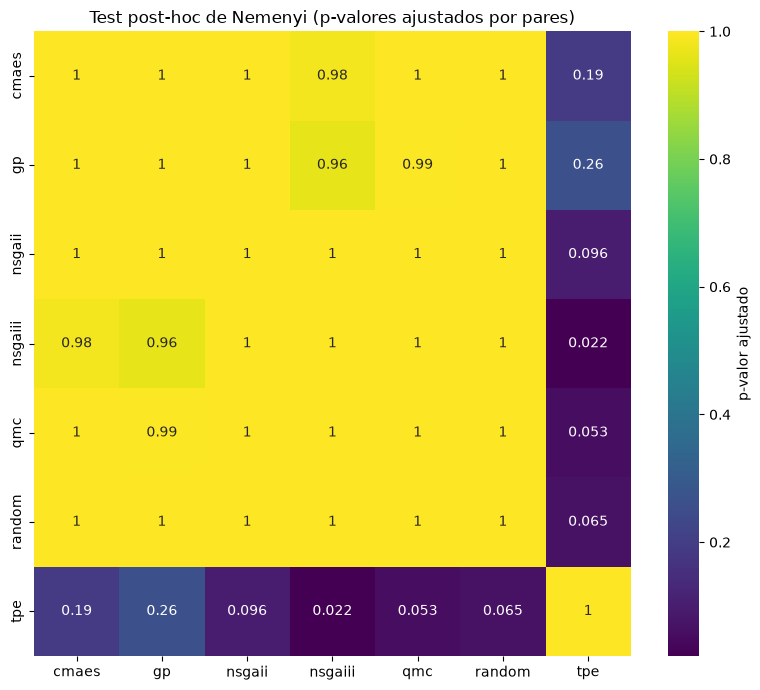

In [7]:
plt.figure(figsize=(8, 7))

sns.heatmap(
    nemenyi,
    annot=True,
    cmap="viridis",
    cbar_kws={"label": "p-valor ajustado"},
)

plt.title("Test post-hoc de Nemenyi (p-valores ajustados por pares)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "nemenyi_heatmap.png", dpi=300)
plt.show()

## Ranking medio

In [8]:
mean_ranks = (
    study_summary
    .groupby("sampler")["rank"]
    .mean()
    .sort_values()
)

mean_ranks

sampler
tpe        2.40
gp         3.95
cmaes      4.05
nsgaii     4.25
random     4.35
qmc        4.40
nsgaiii    4.60
Name: rank, dtype: float64

## Critical Difference Diagram

Representación estándar en la literatura: ordena los *samplers* por ranking medio y une con una barra horizontal aquellos grupos que **no** son estadísticamente distinguibles entre sí (p-valor de Nemenyi > α).


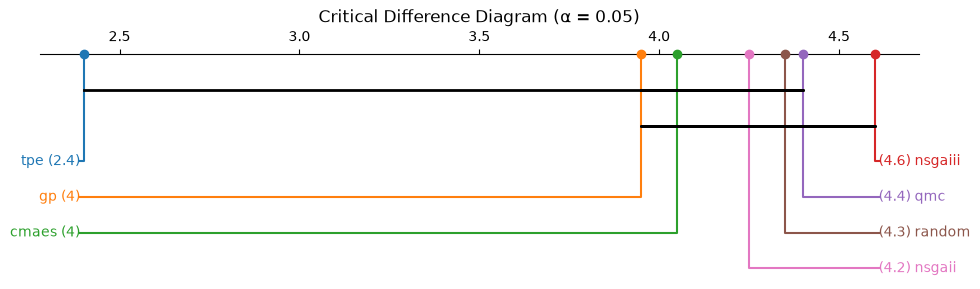

In [9]:
plt.figure(figsize=(10, 3))

sp.critical_difference_diagram(ranks=mean_ranks, sig_matrix=nemenyi)

plt.title("Critical Difference Diagram (α = 0.05)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "critical_distance_diagram.png", dpi=300, bbox_inches="tight")
plt.show()

## Tamaño del efecto: Vargha-Delaney A12

El p-valor solo indica si una diferencia es significativa, no si es grande. El estadístico A12 cuantifica la probabilidad de que un *trial* al azar de un sampler `x` supere a uno de un sampler `y`:

- A12 = 0.5 → no hay diferencia de rendimiento.
- A12 > 0.5 → `x` tiende a superar a `y` (A12 = 0.71 se considera un efecto grande, según Vargha & Delaney, 2000).
- A12 < 0.5 → `y` tiende a superar a `x`.


In [10]:
def vargha_delaney_a12(x, y):
    """Calcula el tamaño del efecto Vargha-Delaney A12 entre dos muestras.

    A12 > 0.5 -> x tiende a superar a y
    A12 < 0.5 -> y tiende a superar a x
    """
    x = np.asarray(x)
    y = np.asarray(y)

    wins = 0
    ties = 0

    for xi in x:
        wins += np.sum(xi > y)
        ties += np.sum(xi == y)

    return (wins + 0.5 * ties) / (len(x) * len(y))

In [11]:
samplers = sorted(study_summary["sampler"].unique())

effect_matrix = pd.DataFrame(index=samplers, columns=samplers, dtype=float)

for s1 in samplers:
    for s2 in samplers:
        a12 = vargha_delaney_a12(
            study_summary.loc[study_summary["sampler"] == s1, "hv_norm"],
            study_summary.loc[study_summary["sampler"] == s2, "hv_norm"],
        )
        effect_matrix.loc[s1, s2] = a12

effect_matrix

,cmaes,gp,nsgaii,nsgaiii,qmc,random,tpe
cmaes,0.50000,0.52125,0.5475,0.58875,0.6025,0.5975,0.28375
gp,0.47875,0.50000,0.5225,0.56125,0.5725,0.5625,0.28375
nsgaii,0.45250,0.47750,0.5000,0.56000,0.5400,0.5525,0.25000
nsgaiii,0.41125,0.43875,0.4400,0.50000,0.4775,0.4950,0.25375
qmc,0.39750,0.42750,0.4600,0.52250,0.5000,0.5125,0.21250
random,0.40250,0.43750,0.4475,0.50500,0.4875,0.5000,0.21750
tpe,0.71625,0.71625,0.7500,0.74625,0.7875,0.7825,0.50000


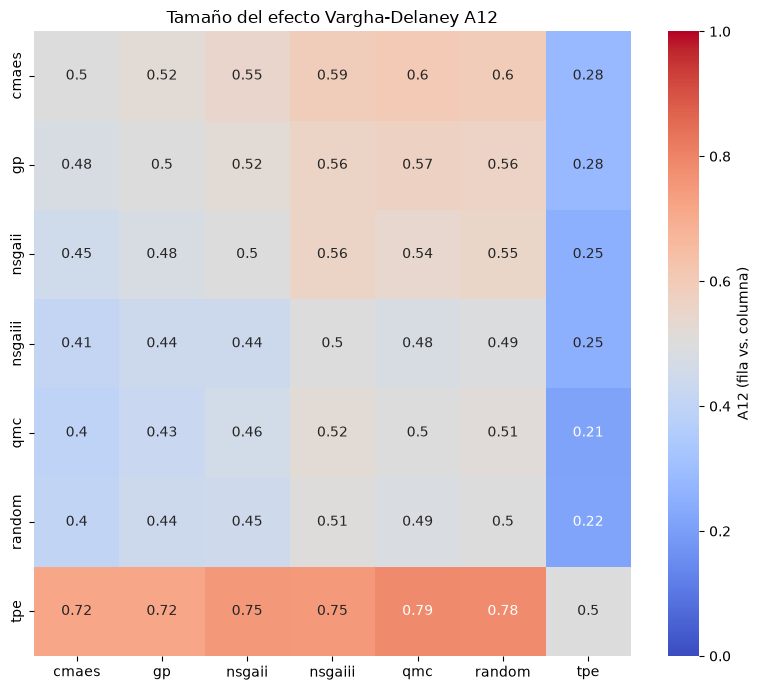

In [12]:
plt.figure(figsize=(8, 7))

sns.heatmap(
    effect_matrix,
    annot=True,
    cmap="coolwarm",
    center=0.5,
    vmin=0,
    vmax=1,
    cbar_kws={"label": "A12 (fila vs. columna)"},
)

plt.title("Tamaño del efecto Vargha-Delaney A12")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "vargha_delaney_matrix.png", dpi=300)
plt.show()

## Grupos estadísticamente indistinguibles (a partir de Nemenyi)

Se derivan directamente de la matriz de Nemenyi: para cada *sampler*, se listan aquellos con los que **no** hay diferencia significativa (p > α). Esto reproduce la información del Critical Difference Diagram en forma de tabla, y se recalcula automáticamente si cambian los datos.


In [13]:
def indistinguishable_from(sampler, nemenyi_matrix, alpha=ALPHA):
    """Devuelve la lista de samplers estadísticamente indistinguibles de `sampler`
    (incluido él mismo), según el test post-hoc de Nemenyi."""
    row = nemenyi_matrix.loc[sampler]
    return sorted(row[row > alpha].index.tolist())


equivalence_groups = {
    s: indistinguishable_from(s, nemenyi) for s in mean_ranks.index
}

for sampler in mean_ranks.index:
    print(f"{sampler:10s} (mean_rank={mean_ranks[sampler]:.2f}) "
          f"~ {equivalence_groups[sampler]}")

tpe        (mean_rank=2.40) ~ ['cmaes', 'gp', 'nsgaii', 'qmc', 'random', 'tpe']
gp         (mean_rank=3.95) ~ ['cmaes', 'gp', 'nsgaii', 'nsgaiii', 'qmc', 'random', 'tpe']
cmaes      (mean_rank=4.05) ~ ['cmaes', 'gp', 'nsgaii', 'nsgaiii', 'qmc', 'random', 'tpe']
nsgaii     (mean_rank=4.25) ~ ['cmaes', 'gp', 'nsgaii', 'nsgaiii', 'qmc', 'random', 'tpe']
random     (mean_rank=4.35) ~ ['cmaes', 'gp', 'nsgaii', 'nsgaiii', 'qmc', 'random', 'tpe']
qmc        (mean_rank=4.40) ~ ['cmaes', 'gp', 'nsgaii', 'nsgaiii', 'qmc', 'random', 'tpe']
nsgaiii    (mean_rank=4.60) ~ ['cmaes', 'gp', 'nsgaii', 'nsgaiii', 'qmc', 'random']


## Tabla resumen

In [14]:
summary_table = (
    study_summary
    .groupby("sampler")
    .agg(
        mean_rank=("rank", "mean"),
        median_rank=("rank", "median"),
        mean_hv=("hv", "mean"),
        std_hv=("hv", "std"),
        mean_hv_norm=("hv_norm", "mean"),
        std_hv_norm=("hv_norm", "std"),
    )
)

In [15]:
winners = (
    study_summary
    .sort_values(["problem", "hv"], ascending=False)
    .groupby("problem")
    .first()
)

wins = winners["sampler"].value_counts()

summary_table["wins"] = wins
summary_table["wins"] = summary_table["wins"].fillna(0).astype(int)

In [16]:
summary_table["indistinguishable_from"] = [
    ", ".join(equivalence_groups[s]) for s in summary_table.index
]

summary_table = summary_table.sort_values("mean_rank")

summary_table = summary_table.round({
    "mean_rank": 2,
    "median_rank": 2,
    "mean_hv": 4,
    "std_hv": 4,
    "mean_hv_norm": 4,
    "std_hv_norm": 4,
})

summary_table

,mean_rank,median_rank,mean_hv,std_hv,mean_hv_norm,std_hv_norm,wins,indistinguishable_from
sampler,,,,,,,,
tpe,2.40,2.0,0.2984,0.2474,0.8014,0.2257,7,"cmaes, gp, nsgaii, qmc, random, tpe"
gp,3.95,4.0,0.2947,0.2465,0.5417,0.3659,3,"cmaes, gp, nsgaii, nsgaiii, qmc, random, tpe"
cmaes,4.05,4.0,0.2965,0.2469,0.5742,0.3558,1,"cmaes, gp, nsgaii, nsgaiii, qmc, random, tpe"
nsgaii,4.25,4.5,0.2965,0.2477,0.5125,0.3544,2,"cmaes, gp, nsgaii, nsgaiii, qmc, random, tpe"
random,4.35,4.0,0.2963,0.2476,0.4548,0.3597,2,"cmaes, gp, nsgaii, nsgaiii, qmc, random, tpe"
qmc,4.40,4.5,0.2960,0.2458,0.4659,0.3297,2,"cmaes, gp, nsgaii, nsgaiii, qmc, random, tpe"
nsgaiii,4.60,5.0,0.2964,0.2475,0.4395,0.3988,3,"cmaes, gp, nsgaii, nsgaiii, qmc, random"


In [17]:
summary_table.to_csv(DATA_DIR / "statistical_summary.csv")
print(f"Guardado: {(DATA_DIR / 'statistical_summary.csv').resolve()}")

Guardado: D:\tfm\tfm\data\processed\statistical_summary.csv


## Conclusiones de este notebook

- El test de Friedman confirma (o descarta) si las diferencias observadas en `02_ranking_global.ipynb` son estadísticamente significativas y no producto del azar.
- Nemenyi + el Critical Difference Diagram identifican **qué pares concretos** de *samplers* difieren.
- Vargha-Delaney cuantifica **cuán grande** es cada diferencia, más allá del p-valor.

Con el ranking estadísticamente validado, el siguiente paso natural es analizar **qué configuraciones de hiperparámetros** explican ese rendimiento (sección de análisis de hiperparámetros) y **a qué coste computacional** se alcanza (`04_convergencia.ipynb`).
